In [9]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

In [2]:
csv_path = "CLEAR_experiments/Sep2026/TIMBER_data_THz1_0916_1.csv"

with open(csv_path) as f:
    variable_name = f.readline().strip()

df = pd.read_csv(csv_path, skiprows=2)
df["Timestamp (LOCAL_TIME)"] = pd.to_datetime(df["Timestamp (LOCAL_TIME)"])
df

ValueError: time data "VARIABLE: CA.BCMTHZ2:Acquisition:charge" doesn't match format "%Y-%m-%d %H:%M:%S.%f". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

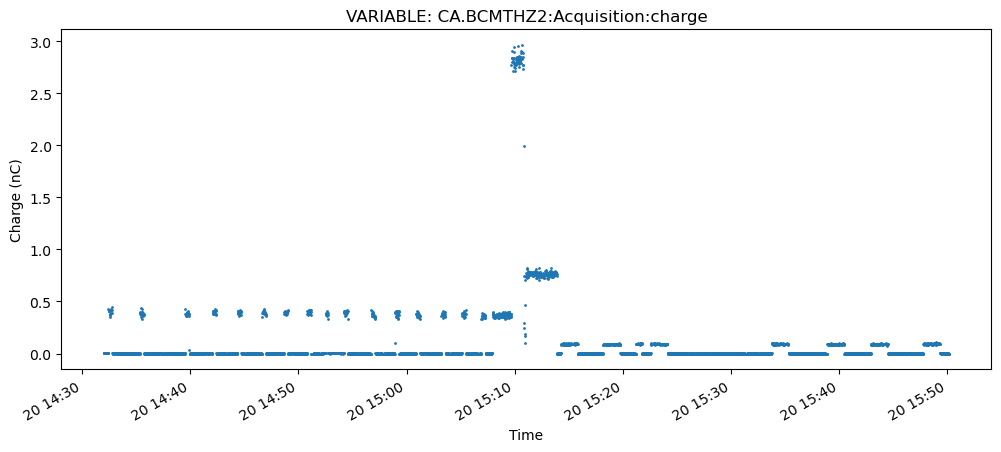

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Timestamp (LOCAL_TIME)"], df["Value"], marker=".", markersize=2, linestyle="none")
ax.set_xlabel("Time")
ax.set_ylabel("Charge (nC)")
ax.set_title(variable_name)
fig.autofmt_xdate()
plt.show()

In [3]:
threshold = 0.05  # nC, separates beam-on shots from the near-zero background/noise floor

beam_on = df["Value"] >= threshold
group_id = (beam_on != beam_on.shift(fill_value=False)).cumsum()

pulses = (
    df[beam_on]
    .groupby(group_id[beam_on])
    .agg(
        start_time=("Timestamp (LOCAL_TIME)", "first"),
        end_time=("Timestamp (LOCAL_TIME)", "last"),
        n_shots=("Value", "size"),
        accumulated_charge=("Value", "sum"),
        average_charge=("Value", "mean"),
    )
    .reset_index(drop=True)
)
pulses


TypeError: '>=' not supported between instances of 'str' and 'float'

## Per-pulse accumulated charge: THz1/THz2/BCM0395 x 0916_1/0916_2/0916_3

Same pulse detection as above (threshold=0.05nC beam-on, grouped into
contiguous pulses), applied to all 9 files, one row per pulse (long format:
`set`, `channel`, `pulse_index`, ...). THz1/THz2 pulse counts match exactly
within each set (same beam shots, two monitors); BCM0395 does not (60/43/63
pulses vs 26/17/23 for THz1/THz2 in 0916_1/2/3) -- same threshold, different
noise floor, so its pulses aren't a 1:1 row match with THz1/THz2's. Long
format avoids misaligning them; filter/pivot as needed.

In [13]:
from io import StringIO


def read_timber_csv(csv_path):
    """Some of these exports (e.g. the THz1 files) have a second
    'VARIABLE: ...' block with a different variable's data appended below
    the first -- stop at that point so only the intended variable's rows
    are read."""
    with open(csv_path) as f:
        lines = f.readlines()
    data_lines = [lines[2]]  # header row
    for line in lines[3:]:
        if line.startswith("VARIABLE:"):
            break
        data_lines.append(line)
    df_i = pd.read_csv(StringIO("".join(data_lines)))
    df_i["Timestamp (LOCAL_TIME)"] = pd.to_datetime(df_i["Timestamp (LOCAL_TIME)"])
    return df_i


def get_pulses(csv_path, threshold=threshold):
    df_i = read_timber_csv(csv_path)
    beam_on_i = df_i["Value"] >= threshold
    group_id_i = (beam_on_i != beam_on_i.shift(fill_value=False)).cumsum()
    return (
        df_i[beam_on_i]
        .groupby(group_id_i[beam_on_i])
        .agg(
            start_time=("Timestamp (LOCAL_TIME)", "first"),
            end_time=("Timestamp (LOCAL_TIME)", "last"),
            n_shots=("Value", "size"),
            accumulated_charge=("Value", "sum"),
            average_charge=("Value", "mean"),
        )
        .reset_index(drop=True)
    )


sets = ["0916_1", "0916_2", "0916_3"]
channel_files = {
    "THz1": "TIMBER_data_THz1_{s}.csv",
    "THz2": "TIMBER_data_THz2_{s}.csv",
    "BCM0395": "TIMBER_data_395_{s}.csv",
}

pulses_by_set = {}
for s in sets:
    channel_tables = []
    for channel_name, pattern in channel_files.items():
        path = f"CLEAR_experiments/Sep2026/{pattern.format(s=s)}"
        p = get_pulses(path)
        p.insert(0, "pulse_index", range(1, len(p) + 1))
        p.insert(0, "channel", channel_name)
        channel_tables.append(p)
    pulses_by_set[s] = pd.concat(channel_tables, ignore_index=True)

In [14]:
pulses_by_set["0916_3"]


,channel,pulse_index,start_time,end_time,n_shots,accumulated_charge,average_charge
0,THz1,1,2026-09-16 18:14:58.826,2026-09-16 18:15:38.409,34,6.125381,0.180158
1,THz1,2,2026-09-16 18:17:08.329,2026-09-16 18:18:29.856,69,12.101969,0.175391
2,THz1,3,2026-09-16 18:20:33.420,2026-09-16 18:22:39.471,106,18.503668,0.174563
3,THz1,4,2026-09-16 18:24:52.752,2026-09-16 18:25:33.582,35,6.004077,0.171545
4,THz1,5,2026-09-16 18:27:28.892,2026-09-16 18:28:49.372,68,11.846508,0.174213
5,THz1,6,2026-09-16 18:30:24.176,2026-09-16 18:32:22.831,100,18.389042,0.183890
6,THz1,7,2026-09-16 18:33:44.367,2026-09-16 18:34:23.951,34,5.963643,0.175401
7,THz1,8,2026-09-16 18:36:14.313,2026-09-16 18:37:33.539,67,11.893804,0.177519
8,THz1,9,2026-09-16 18:38:58.796,2026-09-16 18:40:56.482,99,18.054863,0.182372
9,THz1,10,2026-09-16 18:42:22.955,2026-09-16 18:43:19.396,48,9.325568,0.194283
